In [145]:
import os
from style import *
import requests
import re

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
plt.style.use('dark_background')
pio.templates.default = "plotly_dark"
pio.renderers.default = "notebook_connected"

In [103]:
DATA_DIR = "MyData"
df = pd.read_csv(os.path.join(DATA_DIR, "final.csv"), parse_dates=["Time", "Offline Timestamp"], index_col="Time")
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 38425 entries, 2021-01-06 18:41:06+05:30 to 2023-01-05 21:07:28+05:30
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype                                
---  ------             --------------  -----                                
 0   Platform           38425 non-null  object                               
 1   ms Played          38425 non-null  int64                                
 2   Country            38425 non-null  object                               
 3   IP Address         38425 non-null  object                               
 4   Track Name         38425 non-null  object                               
 5   Artist Name        38425 non-null  object                               
 6   Album Name         38425 non-null  object                               
 7   Spotify URI        38425 non-null  object                               
 8   Reason Start       38425 non-null  object                  

In [104]:
df.head(4).T

Time,2021-01-06 18:41:06+05:30,2021-01-06 18:52:02+05:30,2021-01-06 18:57:00+05:30,2021-01-06 19:01:15+05:30
Platform,"Android OS 10 API 29 (Xiaomi, Redmi Note 7S)","Android OS 10 API 29 (Xiaomi, Redmi Note 7S)","Android OS 10 API 29 (Xiaomi, Redmi Note 7S)","Android OS 10 API 29 (Xiaomi, Redmi Note 7S)"
ms Played,42512,245440,245440,47076
Country,IN,IN,IN,IN
IP Address,47.8.102.145,47.8.102.145,47.8.102.145,47.8.102.145
Track Name,exile (feat. Bon Iver),tolerate it,tolerate it,cardigan
Artist Name,Taylor Swift,Taylor Swift,Taylor Swift,Taylor Swift
Album Name,folklore,evermore,evermore,folklore
Spotify URI,spotify:track:4pvb0WLRcMtbPGmtejJJ6y,spotify:track:0PurA4JVJ8YQgSVopY8fn6,spotify:track:0PurA4JVJ8YQgSVopY8fn6,spotify:track:4R2kfaDFhslZEMJqAFNpdd
Reason Start,clickrow,clickrow,clickrow,playbtn
Reason End,endplay,trackdone,trackdone,unexpected-exit-while-paused


Also, create a column which shows time played in minutes and seconds.

In [182]:
def time_played(ms_played):
    s_played= int(round(ms_played/1000, 0))
    hours = s_played//3600
    s_played-=hours*3600
    minutes = s_played//60
    s_played-=minutes*60
    seconds = s_played%60
    time = f"{hours:02d}:{minutes:02d}:{seconds:02d}"
    return time

In [187]:
time_played(700000)

'00:11:40'

In [188]:
df["Time Played"] = df["ms Played"].apply(time_played)

# Continuos Streaming

The goal is to find the time-ranges with continuos streaming.

This field describes how the track was started. This field can have the following values:

* **trackdone** The previous track played to its end and this was the next track to play. 
* **fwdbtn** The user pressed Next/Forward and this was the next track to play. 
* **clickrow** The user
pressed a specific track in a list of tracks. 
* **backbtn** The user pressed Back and this was the
previous track to play. 
* **playbtn** The user pressed Play on a playlist or other list of tracks.

* **appload** This was the track played the previous time the user used the app, and the user
continued playing this track when the app was started again. 
* **remote** The track was started
on another device and then transferred to this device. 
* **trackerror** The playback of the
previous track ran into some form of error, and this was the next track to play. 
* **unknown or empty**  The reason why the user (or the app) started playing this track is unknown.

In [205]:
def add_times(*args, return_second = False):
    times = list(args)
    second = 0
    regex = re.compile(r"(\d{2}):(\d\d):(\d\d)")
    for time in times:
        res = regex.search(time)
        H, M, S = res.groups()
        if H is not None:
            second += int(H)*3600
        second+=int(M)*60
        second+= int(S)
    if return_second:
        return second
    return time_played(second*1000)


In [209]:
def time_to_seconds(time):
    regex = re.compile(r"(\d{2}):(\d\d):(\d\d)")
    res = regex.search(time)
    H, M, S = res.groups()
    second = int(H)*3600 + int(M)*60 + int(S)
    return second

def time_differece(time1, time2, unit="s"):
    t1_s = time_to_seconds(time1)
    t2_s = time_to_seconds(time2)
    diff = t1_s - t2_s
    if unit == "ms":
        return diff*1000
    return diff

In [192]:
df["Time"] = df.index.strftime("%H:%M:%S")

In [193]:
df["Time Difference"] = df["Offline Timestamp"].diff(1).dt.total_seconds()
df.dropna(inplace=True)

In [197]:
df["Time Difference"] = df["Time Difference"].apply(lambda x: time_played(x*1000))

In [200]:
df[["Reason Start", "Reason End", "Time Played", "Time", "Time Difference"]].tail(30)

,Reason Start,Reason End,Time Played,Time,Time Difference
Time,,,,,
2023-01-05 15:42:02+05:30,trackdone,trackdone,00:03:30,15:42:02,00:03:30
2023-01-05 15:56:57+05:30,trackdone,endplay,00:02:42,15:56:57,00:14:55
2023-01-05 16:01:27+05:30,playbtn,trackdone,00:04:31,16:01:27,00:04:30
2023-01-05 16:05:54+05:30,trackdone,trackdone,00:04:26,16:05:54,00:04:27
2023-01-05 16:13:27+05:30,trackdone,trackdone,00:05:28,16:13:27,00:07:33
2023-01-05 16:52:11+05:30,trackdone,logout,00:00:47,16:52:11,00:38:44
2023-01-05 18:47:57+05:30,appload,logout,00:03:07,18:47:57,01:55:46
2023-01-05 18:52:16+05:30,trackdone,trackdone,00:04:15,18:52:16,00:04:19
2023-01-05 18:55:22+05:30,trackdone,trackdone,00:03:06,18:55:22,00:03:06


In [212]:
def get_difference_in_time(row):
    time_played = row["Time Played"]
    time_diff = row["Time Difference"]
    seconds = time_differece(time_diff, time_played)
    return seconds

In [214]:
df["Diff"] = df.apply(get_difference_in_time, axis=1)

In [353]:
ranges = []
start = None
end = None
started = False
ended = False

for time, diff in zip(df["Diff"].index, df["Diff"].values):
    if diff < 20:
        if started:
            end = time
        else:
            start = time
            end= time
            started = True
    else:
        if started:
            ranges.append((start, end))
            start = None
            end = None
            started = False
            ended = False

In [354]:
len(ranges)

6535

In [357]:
ranges = pd.DataFrame(ranges, columns=["Start", "End"])
diff = ranges["End"] - ranges["Start"]
ranges["Diff"] = diff

In [358]:
ranges.to_csv(os.path.join(DATA_DIR, "range_raw.csv"), index=False)

In [359]:
diff.sort_values(ascending=False).head(20)

2988   0 days 03:31:40
3211   0 days 03:30:42
6500   0 days 03:19:53
2290   0 days 03:14:34
2946   0 days 03:13:11
3380   0 days 03:10:33
2963   0 days 02:51:15
3340   0 days 02:47:54
4285   0 days 02:35:40
5059   0 days 02:30:02
3056   0 days 02:25:29
2690   0 days 02:22:40
2951   0 days 02:20:09
3256   0 days 02:14:38
3348   0 days 02:14:33
2883   0 days 02:14:19
1623   0 days 02:13:26
6410   0 days 02:11:09
2585   0 days 02:10:06
2706   0 days 02:08:55
dtype: timedelta64[ns]

In [362]:
ranges_f = ranges[(diff>pd.Timedelta("00:10:00"))]

In [363]:
ranges_f.to_csv(os.path.join(DATA_DIR, "range.csv"), index=False)

In [368]:
ranges_f[ranges_f["Diff"]>pd.Timedelta("01:00:00")]

,Start,End,Diff
45,2021-01-09 06:20:15+05:30,2021-01-09 07:37:35+05:30,0 days 01:17:20
99,2021-01-12 19:51:56+05:30,2021-01-12 20:59:46+05:30,0 days 01:07:50
151,2021-01-18 06:22:44+05:30,2021-01-18 07:31:17+05:30,0 days 01:08:33
212,2021-01-22 13:07:20+05:30,2021-01-22 14:31:47+05:30,0 days 01:24:27
224,2021-01-23 10:11:27+05:30,2021-01-23 11:42:32+05:30,0 days 01:31:05
...,...,...,...
6419,2022-12-25 10:14:58+05:30,2022-12-25 11:20:38+05:30,0 days 01:05:40
6430,2022-12-26 09:03:57+05:30,2022-12-26 11:08:05+05:30,0 days 02:04:08
6437,2022-12-27 09:06:17+05:30,2022-12-27 10:11:43+05:30,0 days 01:05:26
6500,2023-01-01 20:48:45+05:30,2023-01-02 00:08:38+05:30,0 days 03:19:53


In [394]:
fig  = go.Figure()
fig.add_trace(go.Scatter(x=ranges_f["Start"], y=ranges_f["Diff"], mode="markers"))
#set y limit
# fig.update_yaxes(range=[0,1000])
fig.show()

(0.0, 30.0)

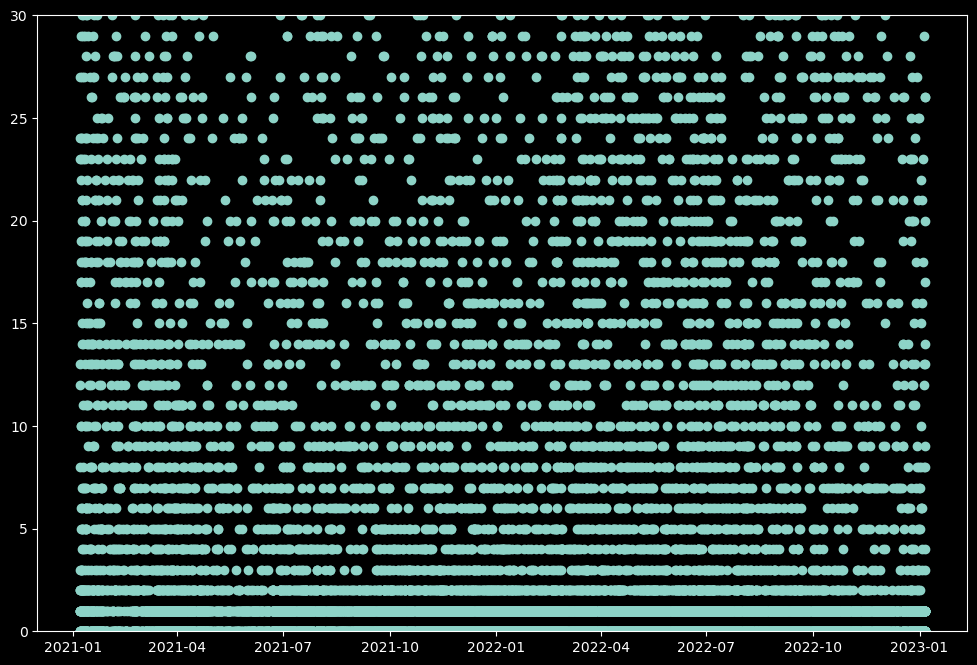

In [384]:
plt.scatter(df.index, df["Diff"].values)
plt.ylim(0, 30)